# GraphSAGE Tutorial: Complete Guide with Mathematical Foundation and Implementation

## Table of Contents
1. [Introduction](#introduction)
2. [Mathematical Foundation](#mathematical-foundation)
3. [Architecture Deep Dive](#architecture-deep-dive)
4. [Implementation](#implementation)
5. [Examples and Use Cases](#examples-and-use-cases)
6. [Advanced Techniques](#advanced-techniques)
7. [Comparison with Other GNNs](#comparison-with-other-gnns)
8. [Best Practices](#best-practices)

## 1. Introduction

### What is GraphSAGE?

GraphSAGE (Graph SAmple and aggreGatE) is a powerful Graph Neural Network architecture introduced by Hamilton et al. in 2017. Unlike traditional Graph Convolutional Networks (GCNs) that require the entire graph structure during training, GraphSAGE can efficiently learn on large graphs through sampling and can generalize to unseen nodes (inductive learning).

### Key Advantages of GraphSAGE:

1. **Inductive Learning**: Can generalize to unseen nodes and graphs
2. **Scalability**: Handles large graphs through neighbor sampling
3. **Flexibility**: Multiple aggregation functions (mean, LSTM, pooling)
4. **Efficiency**: Doesn't require full graph Laplacian computation

### Some Applications:
- Social network analysis
- Protein function prediction
- Citation network classification
- Recommendation systems
- Fraud detection

## 2. Mathematical Foundation

### 2.1 Core Algorithm

GraphSAGE operates through a **sample-and-aggregate** paradigm. For each node, it samples a fixed number of neighbors and aggregates their features.

#### Forward Propagation Algorithm:

For each layer:

1. **Sample neighbors**: For each node v, sample a fixed number of neighbors N(v)
2. **Aggregate**: Compute aggregated representation from neighbors
3. **Update**: Combine node's previous representation with aggregated neighbors

![graphsage](../images/graphsage.jpg)

#### Mathematical Formulation:

**Step 1: Neighbor Sampling**
$$
N_k(v) = SAMPLE(N(v), S_k)
$$
Where:
- $N(v)$: All neighbors of node $v$
- $S_k$: Sample size for layer $k$
- $N_{k(v)}$: Sampled neighbors at layer $k$

**Step 2: Aggregation**
$$
h_{N(v)}^k = AGGREGATE_k({h_u^{k-1}, ∀u ∈ N_{k(v)}})
$$

**Step 3: Update**
$$
h_{v^k} = σ(W^k · CONCAT(h_v^{k-1}, h_{N(v)}^k))
$$

Where:
- $h_v^k$: Node $v$'s representation at layer $k$
- $W^k$: Learnable weight matrix at layer $k$
- σ: Activation function (e.g., ReLU)
- CONCAT: Concatenation operation

### 2.2 Aggregation Functions

GraphSAGE supports multiple aggregation functions:

#### 2.2.1 Mean Aggregator
$$
h_{N(v)}^k = MEAN({h_u^{k-1}, ∀u ∈ N_{k(v)}})
$$

The mean aggregator is:
- **Symmetric**: Order of neighbors doesn't matter
- **Differentiable**: Allows gradient-based optimization
- **Simple**: Computationally efficient

#### 2.2.2 LSTM Aggregator
$$
h_{N(v)}^k = LSTM({h_u^{k-1}, ∀u ∈ N_{k(v)}})
$$

The LSTM aggregator:
- **Sequential**: Processes neighbors in random order
- **Expressive**: Can capture complex neighbor interactions
- **Asymmetric**: Different orderings can produce different results

#### 2.2.3 Pooling Aggregator
$$
h_{N(v)}^k = max({σ(W_{pool} h_u^{k-1} + b), ∀u ∈ N_k(v)})
$$

The pooling aggregator:
- **Symmetric**: Order-invariant like mean
- **Selective**: Focuses on most important features
- **Non-linear**: Captures complex patterns

### 2.3 Neighborhood Sampling Strategy


#### 🔹 Uniform Sampling

In **uniform sampling**, each neighbor has an equal probability of being selected:

$$
P(u \in N_k(v)) = \frac{1}{|N(v)|} \quad \forall u \in N(v)
$$

That is, neighbors are sampled uniformly at random from the set of neighbors of node $v$.

---

#### 🔹 Importance Sampling

In **importance sampling**, neighbors are sampled with probability proportional to an importance score or edge weight:

$$
P(u \in N_k(v)) \propto w(v, u)
$$

Here, $w(v, u)$ denotes the weight or importance score of the edge between nodes $v$ and $u$.

---

### 2.4 Loss Functions in Graph Representation Learning
####  Node Classification

For **node classification**, the cross-entropy loss is computed over the labeled nodes:

$$
\mathcal{L}_{\text{node}} = -\sum_{v \in \mathcal{V}_{\text{train}}} \sum_{c=1}^{C} y_{v,c} \log \left( \sigma(h_v^{(K)})_c \right)
$$

- $h_v^{(K)}$: Final representation of node $v$ after $K$ GNN layers  
- $y_{v,c}$: One-hot encoded label of node $v$ for class $c$  
- $\sigma$: Softmax function producing class probabilities  
- $\mathcal{V}_{\text{train}}$: Set of labeled training nodes

---

####  Graph Classification

For **graph classification**, the loss is similarly computed at the graph level:

$$
\mathcal{L}_{\text{graph}} = -\sum_{G \in \mathcal{G}_{\text{train}}} \sum_{c=1}^{C} y_{G,c} \log \left( \sigma(\text{READOUT}(G))_c \right)
$$

- $\text{READOUT}(G)$: Graph-level embedding produced by a readout function (e.g., mean, sum, max)  
- $y_{G,c}$: One-hot encoded label for graph $G$  
- $\mathcal{G}_{\text{train}}$: Set of labeled training graphs



Where READOUT can be:
- Mean pooling: $READOUT(G) = MEAN({h_v^K, ∀v ∈ G})$
- Max pooling: $READOUT(G) = MAX({h_v^K, ∀v ∈ G})$
- Sum pooling: $READOUT(G) = SUM({h_v^K, ∀v ∈ G})$

### 2.5 Normalization

GraphSAGE applies L2 normalization to node representations:
$$
h_v^k = h_v^k / ||h_v^k||_2
$$

This normalization:
- Prevents exploding gradients
- Improves training stability
- Enables better generalization

## 3. Architecture Deep Dive

### 3.1 Multi-Layer Architecture

```
Input Features (X) → GraphSAGE Layer 1 → ... → GraphSAGE Layer K → Output
```

Each layer transforms node representations by:
1. Sampling neighbors
2. Aggregating neighbor features
3. Combining with node's own features
4. Applying non-linear transformation

### 3.2 Inductive vs Transductive Learning

**Transductive Learning** (Traditional GCN):
- Requires all nodes during training
- Cannot generalize to unseen nodes
- Uses global graph structure

**Inductive Learning** (GraphSAGE):
- Learns from node features and local structure
- Can generalize to unseen nodes
- Uses learned aggregation functions

### 3.3 Computational Complexity

For a K-layer GraphSAGE:
- **Time Complexity**: $O(K × |V| × S^K × D)$
- **Space Complexity**: $O(|V| × D)$

Where:
- $K$: Number of layers
- $|V|$: Number of nodes
- $S$: Sample size per layer
- $D$: Feature dimension

## 4. Implementation

### 4.1 Basic GraphSAGE Implementation


GraphSAGE Tutorial: Comprehensive Implementation

1. Creating synthetic graph...


C:\Users\sashk\anaconda3\envs\mlgBookPro\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Graph Statistics:
- Nodes: 1000
- Edges: 9684
- Features: 32
- Classes: 3

2. Training basic GraphSAGE...
Epoch 000, Train Loss: 1.0991, Train Acc: 0.4633, Val Loss: 1.0895, Val Acc: 0.4150
Epoch 020, Train Loss: 0.5125, Train Acc: 0.9717, Val Loss: 0.5501, Val Acc: 0.9400
Epoch 040, Train Loss: 0.2023, Train Acc: 0.9967, Val Loss: 0.2573, Val Acc: 0.9300
Epoch 060, Train Loss: 0.1319, Train Acc: 1.0000, Val Loss: 0.1951, Val Acc: 0.9350
Epoch 080, Train Loss: 0.0979, Train Acc: 1.0000, Val Loss: 0.1658, Val Acc: 0.9600
Epoch 100, Train Loss: 0.0852, Train Acc: 1.0000, Val Loss: 0.1672, Val Acc: 0.9500
Epoch 120, Train Loss: 0.0702, Train Acc: 1.0000, Val Loss: 0.1499, Val Acc: 0.9550
Epoch 140, Train Loss: 0.0713, Train Acc: 1.0000, Val Loss: 0.1459, Val Acc: 0.9550
Epoch 160, Train Loss: 0.0623, Train Acc: 1.0000, Val Loss: 0.1340, Val Acc: 0.9550
Epoch 180, Train Loss: 0.0618, Train Acc: 1.0000, Val Loss: 0.1448, Val Acc: 0.9550

3. Evaluating model...
Test Accuracy: 0.9350

4. Plot

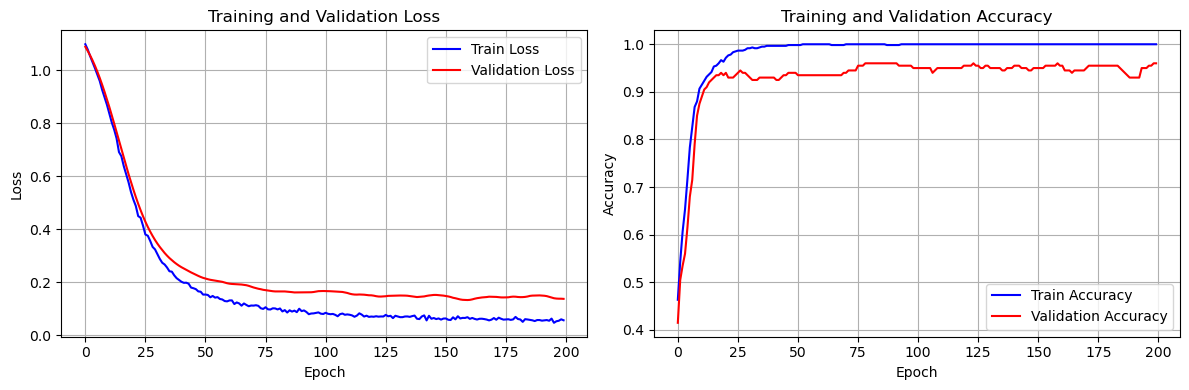


5. Plotting confusion matrix...


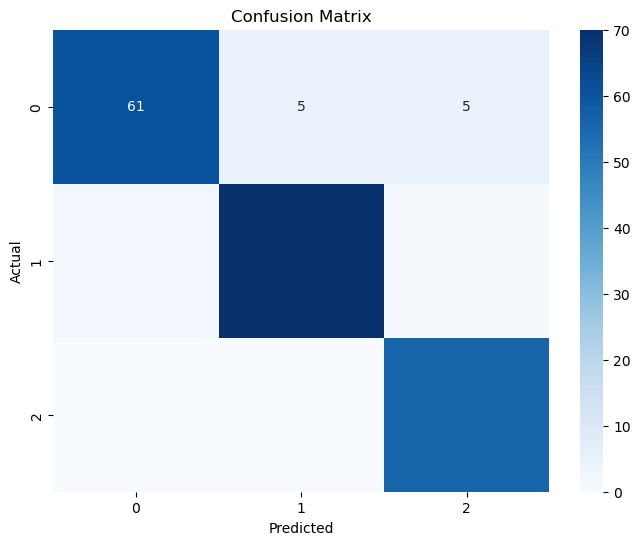


6. Visualizing node embeddings...


AttributeError: 'GraphSAGEPyG' object has no attribute 'layers'

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, GCNConv
from torch_geometric.data import Data, DataLoader
from torch_geometric.utils import to_networkx, subgraph
import torch_geometric.transforms as T
from torch_geometric.loader import NeighborSampler
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
from typing import List, Tuple, Optional
import random
from collections import defaultdict

class GraphSAGELayer(nn.Module):
    """
    Custom GraphSAGE layer implementation with multiple aggregation functions.
    """
    
    def __init__(self, in_dim: int, out_dim: int, aggregator: str = 'mean', 
                 bias: bool = True, normalize: bool = True):
        """
        Initialize GraphSAGE layer.
        
        Args:
            in_dim: Input feature dimension
            out_dim: Output feature dimension
            aggregator: Type of aggregation ('mean', 'max', 'lstm', 'pool')
            bias: Whether to use bias
            normalize: Whether to apply L2 normalization
        """
        super(GraphSAGELayer, self).__init__()
        
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.aggregator = aggregator
        self.normalize = normalize
        
        # Weight matrices
        self.W_self = nn.Linear(in_dim, out_dim, bias=bias)
        self.W_neigh = nn.Linear(in_dim, out_dim, bias=bias)
        
        # Aggregator-specific components
        if aggregator == 'lstm':
            self.lstm = nn.LSTM(in_dim, in_dim, batch_first=True)
        elif aggregator == 'pool':
            self.pool_mlp = nn.Sequential(
                nn.Linear(in_dim, in_dim),
                nn.ReLU(),
                nn.Linear(in_dim, in_dim)
            )
        
        self.reset_parameters()
    
    def reset_parameters(self):
        """Initialize parameters."""
        nn.init.xavier_uniform_(self.W_self.weight)
        nn.init.xavier_uniform_(self.W_neigh.weight)
        
        if self.aggregator == 'lstm':
            self.lstm.reset_parameters()
        elif self.aggregator == 'pool':
            for layer in self.pool_mlp:
                if isinstance(layer, nn.Linear):
                    nn.init.xavier_uniform_(layer.weight)
    
    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, 
                size: Optional[Tuple[int, int]] = None) -> torch.Tensor:
        """
        Forward pass of GraphSAGE layer.
        
        Args:
            x: Node features [num_nodes, in_dim]
            edge_index: Edge indices [2, num_edges]
            size: Size of source and target nodes
            
        Returns:
            Updated node features [num_nodes, out_dim]
        """
        
        # Separate source and target nodes
        if size is None:
            size = (x.size(0), x.size(0))
        
        # Get neighbor features
        row, col = edge_index
        x_neigh = x[row]  # Source node features
        
        # Aggregate neighbor features
        if self.aggregator == 'mean':
            x_agg = self.mean_aggregator(x_neigh, col, size[1])
        elif self.aggregator == 'max':
            x_agg = self.max_aggregator(x_neigh, col, size[1])
        elif self.aggregator == 'lstm':
            x_agg = self.lstm_aggregator(x_neigh, col, size[1])
        elif self.aggregator == 'pool':
            x_agg = self.pool_aggregator(x_neigh, col, size[1])
        else:
            raise ValueError(f"Unknown aggregator: {self.aggregator}")
        
        # Update node features
        x_self = self.W_self(x[:size[1]])
        x_neigh_agg = self.W_neigh(x_agg)
        
        out = x_self + x_neigh_agg
        
        # Apply activation
        out = F.relu(out)
        
        # L2 normalization
        if self.normalize:
            out = F.normalize(out, p=2, dim=1)
        
        return out
    
    def mean_aggregator(self, x_neigh: torch.Tensor, col: torch.Tensor, 
                       num_nodes: int) -> torch.Tensor:
        """Mean aggregation function."""
        return torch.zeros(num_nodes, self.in_dim, device=x_neigh.device).scatter_add_(
            0, col.unsqueeze(1).expand(-1, self.in_dim), x_neigh
        ) / torch.bincount(col, minlength=num_nodes).float().clamp(min=1).unsqueeze(1)
    
    def max_aggregator(self, x_neigh: torch.Tensor, col: torch.Tensor, 
                      num_nodes: int) -> torch.Tensor:
        """Max aggregation function."""
        out = torch.full((num_nodes, self.in_dim), float('-inf'), device=x_neigh.device)
        return out.scatter_reduce_(0, col.unsqueeze(1).expand(-1, self.in_dim), 
                                  x_neigh, reduce='amax', include_self=False)
    
    def lstm_aggregator(self, x_neigh: torch.Tensor, col: torch.Tensor, 
                       num_nodes: int) -> torch.Tensor:
        """LSTM aggregation function."""
        # Group neighbors by target node
        neighbors = defaultdict(list)
        for i, target in enumerate(col):
            neighbors[target.item()].append(x_neigh[i])
        
        # Apply LSTM to each node's neighbors
        out = torch.zeros(num_nodes, self.in_dim, device=x_neigh.device)
        for node, neigh_features in neighbors.items():
            if len(neigh_features) > 0:
                # Stack and process through LSTM
                neigh_tensor = torch.stack(neigh_features).unsqueeze(0)
                _, (hidden, _) = self.lstm(neigh_tensor)
                out[node] = hidden[-1, 0]  # Take last hidden state
        
        return out
    
    def pool_aggregator(self, x_neigh: torch.Tensor, col: torch.Tensor, 
                       num_nodes: int) -> torch.Tensor:
        """Pooling aggregation function."""
        # Apply MLP to neighbor features
        pooled_neigh = self.pool_mlp(x_neigh)
        
        # Max pooling
        out = torch.full((num_nodes, self.in_dim), float('-inf'), device=x_neigh.device)
        return out.scatter_reduce_(0, col.unsqueeze(1).expand(-1, self.in_dim), 
                                  pooled_neigh, reduce='amax', include_self=False)

class GraphSAGE(nn.Module):
    """
    Multi-layer GraphSAGE model for node classification.
    """
    
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, 
                 num_layers: int = 2, aggregator: str = 'mean', 
                 dropout: float = 0.5, normalize: bool = True):
        """
        Initialize GraphSAGE model.
        
        Args:
            in_dim: Input feature dimension
            hidden_dim: Hidden layer dimension
            out_dim: Output dimension (number of classes)
            num_layers: Number of GraphSAGE layers
            aggregator: Aggregation function type
            dropout: Dropout probability
            normalize: Whether to apply L2 normalization
        """
        super(GraphSAGE, self).__init__()
        
        self.num_layers = num_layers
        self.dropout = dropout
        
        # GraphSAGE layers
        self.layers = nn.ModuleList()
        
        # First layer
        self.layers.append(GraphSAGELayer(in_dim, hidden_dim, aggregator, normalize=normalize))
        
        # Hidden layers
        for _ in range(num_layers - 2):
            self.layers.append(GraphSAGELayer(hidden_dim, hidden_dim, aggregator, normalize=normalize))
        
        # Output layer
        if num_layers > 1:
            self.layers.append(GraphSAGELayer(hidden_dim, out_dim, aggregator, normalize=False))
        else:
            # Single layer case
            self.layers[0] = GraphSAGELayer(in_dim, out_dim, aggregator, normalize=False)
    
    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through GraphSAGE layers.
        
        Args:
            x: Node features [num_nodes, in_dim]
            edge_index: Edge indices [2, num_edges]
            
        Returns:
            Node representations [num_nodes, out_dim]
        """
        
        for i, layer in enumerate(self.layers):
            x = layer(x, edge_index)
            
            # Apply dropout (except for last layer)
            if i < len(self.layers) - 1:
                x = F.dropout(x, p=self.dropout, training=self.training)
        
        return x
    
    def inference(self, x: torch.Tensor, edge_index: torch.Tensor, 
                  batch_size: int = 1024) -> torch.Tensor:
        """
        Inference mode with neighbor sampling for large graphs.
        """
        # For simplicity, we'll use the regular forward pass
        # In practice, you'd implement batch-wise inference with sampling
        return self.forward(x, edge_index)

class GraphSAGEPyG(nn.Module):
    """
    GraphSAGE implementation using PyTorch Geometric's SAGEConv.
    """
    
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, 
                 num_layers: int = 2, dropout: float = 0.5, 
                 aggregator: str = 'mean', normalize: bool = True):
        super(GraphSAGEPyG, self).__init__()
        
        self.num_layers = num_layers
        self.dropout = dropout
        
        self.convs = nn.ModuleList()
        
        # First layer
        self.convs.append(SAGEConv(in_dim, hidden_dim, aggr=aggregator, normalize=normalize))
        
        # Hidden layers
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim, aggr=aggregator, normalize=normalize))
        
        # Output layer
        if num_layers > 1:
            self.convs.append(SAGEConv(hidden_dim, out_dim, aggr=aggregator, normalize=False))
        else:
            self.convs[0] = SAGEConv(in_dim, out_dim, aggr=aggregator, normalize=False)
    
    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            
            if i < len(self.convs) - 1:
                x = F.relu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        
        return x

def create_synthetic_graph(num_nodes: int = 1000, num_features: int = 32, 
                          num_classes: int = 3, avg_degree: int = 5) -> Data:
    """
    Create a synthetic graph for demonstration.
    
    Args:
        num_nodes: Number of nodes
        num_features: Number of node features
        num_classes: Number of classes
        avg_degree: Average node degree
        
    Returns:
        PyTorch Geometric Data object
    """
    
    # Generate random features
    x = torch.randn(num_nodes, num_features)
    
    # Create random graph structure (ensuring connectivity)
    edges = []
    
    # Create a connected graph using preferential attachment
    for i in range(1, num_nodes):
        # Connect to existing nodes with probability proportional to degree
        if i == 1:
            edges.append([0, 1])
        else:
            # Get node degrees
            degrees = defaultdict(int)
            for edge in edges:
                degrees[edge[0]] += 1
                degrees[edge[1]] += 1
            
            # Sample number of connections
            num_connections = min(np.random.poisson(avg_degree), i)
            
            # Select nodes to connect to
            probabilities = np.array([degrees[j] + 1 for j in range(i)])
            probabilities = probabilities / probabilities.sum()
            
            targets = np.random.choice(i, size=num_connections, 
                                     replace=False, p=probabilities)
            
            for target in targets:
                edges.append([i, target])
    
    # Convert to tensor
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    
    # Make undirected
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)
    
    # Remove self-loops and duplicates
    edge_index = torch.unique(edge_index, dim=1)
    
    # Generate labels based on node features and structure
    # Use a simple heuristic: cluster based on feature similarity
    from sklearn.cluster import KMeans
    
    kmeans = KMeans(n_clusters=num_classes, random_state=42)
    y = torch.tensor(kmeans.fit_predict(x.numpy()), dtype=torch.long)
    
    # Create train/val/test masks
    num_train = int(0.6 * num_nodes)
    num_val = int(0.2 * num_nodes)
    
    indices = torch.randperm(num_nodes)
    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    val_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)
    
    train_mask[indices[:num_train]] = True
    val_mask[indices[num_train:num_train + num_val]] = True
    test_mask[indices[num_train + num_val:]] = True
    
    data = Data(x=x, edge_index=edge_index, y=y, 
                train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)
    
    return data

def train_graphsage(model: nn.Module, data: Data, num_epochs: int = 200, 
                   learning_rate: float = 0.01, weight_decay: float = 5e-4) -> dict:
    """
    Train GraphSAGE model.
    
    Args:
        model: GraphSAGE model
        data: Graph data
        num_epochs: Number of training epochs
        learning_rate: Learning rate
        weight_decay: Weight decay for regularization
        
    Returns:
        Training history dictionary
    """
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    data = data.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    model.train()
    for epoch in range(num_epochs):
        # Training step
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        
        train_loss = criterion(out[data.train_mask], data.y[data.train_mask])
        train_loss.backward()
        optimizer.step()
        
        # Evaluation
        model.eval()
        with torch.no_grad():
            out = model(data.x, data.edge_index)
            
            # Training metrics
            train_pred = out[data.train_mask].argmax(dim=1)
            train_acc = (train_pred == data.y[data.train_mask]).float().mean()
            
            # Validation metrics
            val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
            val_pred = out[data.val_mask].argmax(dim=1)
            val_acc = (val_pred == data.y[data.val_mask]).float().mean()
        
        history['train_loss'].append(train_loss.item())
        history['train_acc'].append(train_acc.item())
        history['val_loss'].append(val_loss.item())
        history['val_acc'].append(val_acc.item())
        
        if epoch % 20 == 0:
            print(f'Epoch {epoch:03d}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, '
                  f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
        
        model.train()
    
    return history

def evaluate_model(model: nn.Module, data: Data) -> dict:
    """
    Evaluate trained model on test set.
    
    Args:
        model: Trained GraphSAGE model
        data: Graph data
        
    Returns:
        Evaluation metrics dictionary
    """
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    data = data.to(device)
    
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        
        # Test predictions
        test_pred = out[data.test_mask].argmax(dim=1)
        test_acc = (test_pred == data.y[data.test_mask]).float().mean()
        
        # Convert to numpy for sklearn metrics
        y_true = data.y[data.test_mask].cpu().numpy()
        y_pred = test_pred.cpu().numpy()
        
        # Calculate detailed metrics
        report = classification_report(y_true, y_pred, output_dict=True)
        
        results = {
            'test_accuracy': test_acc.item(),
            'classification_report': report,
            'y_true': y_true,
            'y_pred': y_pred
        }
    
    return results

def plot_training_history(history: dict):
    """Plot training history."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss plot
    ax1.plot(history['train_loss'], label='Train Loss', color='blue')
    ax1.plot(history['val_loss'], label='Validation Loss', color='red')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Accuracy plot
    ax2.plot(history['train_acc'], label='Train Accuracy', color='blue')
    ax2.plot(history['val_acc'], label='Validation Accuracy', color='red')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, class_names: List[str] = None):
    """Plot confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names or range(len(np.unique(y_true))),
                yticklabels=class_names or range(len(np.unique(y_true))))
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

def visualize_graph_embeddings(model: nn.Module, data: Data, layer_idx: int = -1):
    """Visualize learned node embeddings using t-SNE."""
    from sklearn.manifold import TSNE
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    data = data.to(device)
    
    model.eval()
    with torch.no_grad():
        # Get embeddings from specified layer
        x = data.x
        for i, layer in enumerate(model.layers):
            x = layer(x, data.edge_index)
            if i == layer_idx:
                embeddings = x.cpu().numpy()
                break
        else:
            embeddings = x.cpu().numpy()
    
    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    embeddings_2d = tsne.fit_transform(embeddings)
    
    # Plot
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                         c=data.y.cpu().numpy(), cmap='tab10', alpha=0.7)
    plt.colorbar(scatter)
    plt.title(f'Node Embeddings Visualization (Layer {layer_idx})')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.show()

def compare_aggregators(data: Data, aggregators: List[str] = ['mean', 'max', 'pool']):
    """Compare different aggregation functions."""
    
    results = {}
    
    for agg in aggregators:
        print(f"\n--- Training with {agg} aggregator ---")
        
        # Create model
        model = GraphSAGEPyG(
            in_dim=data.x.size(1),
            hidden_dim=64,
            out_dim=len(torch.unique(data.y)),
            num_layers=2,
            aggregator=agg,
            dropout=0.5
        )
        
        # Train model
        history = train_graphsage(model, data, num_epochs=200)
        
        # Evaluate
        eval_results = evaluate_model(model, data)
        
        results[agg] = {
            'history': history,
            'test_accuracy': eval_results['test_accuracy'],
            'model': model
        }
        
        print(f"Test Accuracy: {eval_results['test_accuracy']:.4f}")
    
    # Plot comparison
    plt.figure(figsize=(12, 4))
    
    # Validation accuracy comparison
    plt.subplot(1, 2, 1)
    for agg in aggregators:
        plt.plot(results[agg]['history']['val_acc'], label=f'{agg} aggregator')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy')
    plt.title('Validation Accuracy by Aggregator')
    plt.legend()
    plt.grid(True)
    
    # Test accuracy comparison
    plt.subplot(1, 2, 2)
    test_accs = [results[agg]['test_accuracy'] for agg in aggregators]
    plt.bar(aggregators, test_accs)
    plt.ylabel('Test Accuracy')
    plt.title('Test Accuracy by Aggregator')
    plt.grid(True, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    return results

def demonstrate_inductive_learning():
    """
    Demonstrate GraphSAGE's inductive learning capability.
    
    This function shows how GraphSAGE can generalize to unseen nodes
    by training on a subset of the graph and testing on new nodes.
    """
    
    print("=== Demonstrating Inductive Learning ===")
    
    # Create larger graph for demonstration
    full_data = create_synthetic_graph(num_nodes=2000, num_features=32, 
                                     num_classes=3, avg_degree=6)
    
    # Split into training graph (first 1000 nodes) and test graph (remaining nodes)
    train_nodes = torch.arange(1000)
    test_nodes = torch.arange(1000, 2000)
    
    # Create training subgraph
    train_edge_mask = torch.isin(full_data.edge_index[0], train_nodes) & \
                     torch.isin(full_data.edge_index[1], train_nodes)
    train_edge_index = full_data.edge_index[:, train_edge_mask]
    
    # Remap node indices for training subgraph
    node_mapping = {old_idx.item(): new_idx for new_idx, old_idx in enumerate(train_nodes)}
    train_edge_index_remapped = torch.tensor([
        [node_mapping[edge[0].item()], node_mapping[edge[1].item()]]
        for edge in train_edge_index.t()
    ]).t()
    
    # Create training data
    train_data = Data(
        x=full_data.x[train_nodes],
        edge_index=train_edge_index_remapped,
        y=full_data.y[train_nodes]
    )
    
    # Create train/val split within training nodes
    num_train = int(0.8 * len(train_nodes))
    train_indices = torch.randperm(len(train_nodes))
    
    train_data.train_mask = torch.zeros(len(train_nodes), dtype=torch.bool)
    train_data.val_mask = torch.zeros(len(train_nodes), dtype=torch.bool)
    train_data.train_mask[train_indices[:num_train]] = True
    train_data.val_mask[train_indices[num_train:]] = True
    
    # Train GraphSAGE on training subgraph
    print("Training GraphSAGE on training subgraph...")
    model = GraphSAGEPyG(
        in_dim=train_data.x.size(1),
        hidden_dim=64,
        out_dim=len(torch.unique(train_data.y)),
        num_layers=2,
        aggregator='mean',
        dropout=0.5
    )
    
    history = train_graphsage(model, train_data, num_epochs=150)
    
    # Test on unseen nodes
    print("\nTesting on unseen nodes...")
    
    # Create test subgraph (including connections to training nodes)
    test_edge_mask = torch.isin(full_data.edge_index[0], test_nodes) | \
                    torch.isin(full_data.edge_index[1], test_nodes)
    test_edge_index = full_data.edge_index[:, test_edge_mask]
    
    # For simplicity, we'll test on the full graph
    # In practice, you might want to sample neighbors from the training set
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    full_data = full_data.to(device)
    
    model.eval()
    with torch.no_grad():
        out = model(full_data.x, full_data.edge_index)
        
        # Evaluate on test nodes
        test_pred = out[test_nodes].argmax(dim=1)
        test_acc = (test_pred == full_data.y[test_nodes]).float().mean()
        
        print(f"Inductive Test Accuracy: {test_acc:.4f}")
    
    return model, history, test_acc

def create_citation_network_example():
    """
    Create a citation network example for node classification.
    
    This simulates a paper citation network where:
    - Nodes represent papers
    - Edges represent citation relationships
    - Node features represent paper abstracts (simulated)
    - Labels represent paper categories
    """
    
    print("=== Creating Citation Network Example ===")
    
    # Simulate paper data
    num_papers = 1500
    num_features = 128  # Simulated abstract features
    num_categories = 5
    
    # Generate paper features (simulated abstract embeddings)
    np.random.seed(42)
    paper_features = np.random.randn(num_papers, num_features)
    
    # Create citation network with realistic structure
    edges = []
    
    # Papers cite older papers with higher probability
    for i in range(num_papers):
        # Number of citations (references)
        num_citations = np.random.poisson(8)  # Average 8 citations per paper
        
        if i > 0:  # Can't cite future papers
            # Probability of citing decreases with age difference
            cite_probs = np.exp(-0.1 * np.arange(i)) + 0.01
            cite_probs = cite_probs / cite_probs.sum()
            
            # Sample papers to cite
            cited_papers = np.random.choice(
                i, size=min(num_citations, i), replace=False, p=cite_probs
            )
            
            for cited_paper in cited_papers:
                edges.append([i, cited_paper])  # i cites cited_paper
    
    # Convert to PyTorch tensors
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    x = torch.tensor(paper_features, dtype=torch.float)
    
    # Generate categories based on feature similarity
    from sklearn.cluster import KMeans
    kmeans = KMeans(n_clusters=num_categories, random_state=42)
    y = torch.tensor(kmeans.fit_predict(paper_features), dtype=torch.long)
    
    # Create temporal split (older papers for training, newer for testing)
    train_ratio = 0.6
    val_ratio = 0.2
    
    split_1 = int(train_ratio * num_papers)
    split_2 = int((train_ratio + val_ratio) * num_papers)
    
    train_mask = torch.zeros(num_papers, dtype=torch.bool)
    val_mask = torch.zeros(num_papers, dtype=torch.bool)
    test_mask = torch.zeros(num_papers, dtype=torch.bool)
    
    train_mask[:split_1] = True
    val_mask[split_1:split_2] = True
    test_mask[split_2:] = True
    
    data = Data(x=x, edge_index=edge_index, y=y,
                train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)
    
    print(f"Citation Network Statistics:")
    print(f"- Number of papers: {num_papers}")
    print(f"- Number of citations: {edge_index.size(1)}")
    print(f"- Number of categories: {num_categories}")
    print(f"- Average citations per paper: {edge_index.size(1) / num_papers:.2f}")
    
    return data

def main_tutorial():
    """
    Main tutorial function demonstrating GraphSAGE capabilities.
    """
    
    print("=" * 60)
    print("GraphSAGE Tutorial: Comprehensive Implementation")
    print("=" * 60)
    
    # 1. Create synthetic graph
    print("\n1. Creating synthetic graph...")
    data = create_synthetic_graph(num_nodes=1000, num_features=32, 
                                 num_classes=3, avg_degree=5)
    
    print(f"Graph Statistics:")
    print(f"- Nodes: {data.x.size(0)}")
    print(f"- Edges: {data.edge_index.size(1)}")
    print(f"- Features: {data.x.size(1)}")
    print(f"- Classes: {len(torch.unique(data.y))}")
    
    # 2. Train basic GraphSAGE
    print("\n2. Training basic GraphSAGE...")
    model = GraphSAGEPyG(
        in_dim=data.x.size(1),
        hidden_dim=64,
        out_dim=len(torch.unique(data.y)),
        num_layers=2,
        aggregator='mean',
        dropout=0.5
    )
    
    history = train_graphsage(model, data, num_epochs=200)
    
    # 3. Evaluate model
    print("\n3. Evaluating model...")
    results = evaluate_model(model, data)
    print(f"Test Accuracy: {results['test_accuracy']:.4f}")
    
    # 4. Plot training history
    print("\n4. Plotting training history...")
    plot_training_history(history)
    
    # 5. Plot confusion matrix
    print("\n5. Plotting confusion matrix...")
    plot_confusion_matrix(results['y_true'], results['y_pred'])
    
    # 6. Visualize embeddings
    print("\n6. Visualizing node embeddings...")
    visualize_graph_embeddings(model, data)
    
    # 7. Compare aggregators
    print("\n7. Comparing different aggregators...")
    aggregator_results = compare_aggregators(data, ['mean', 'max', 'pool'])
    
    # 8. Demonstrate inductive learning
    print("\n8. Demonstrating inductive learning...")
    inductive_model, inductive_history, inductive_acc = demonstrate_inductive_learning()
    
    # 9. Citation network example
    print("\n9. Citation network example...")
    citation_data = create_citation_network_example()
    
    # Train on citation network
    citation_model = GraphSAGEPyG(
        in_dim=citation_data.x.size(1),
        hidden_dim=128,
        out_dim=len(torch.unique(citation_data.y)),
        num_layers=3,
        aggregator='mean',
        dropout=0.3
    )
    
    citation_history = train_graphsage(citation_model, citation_data, num_epochs=150)
    citation_results = evaluate_model(citation_model, citation_data)
    
    print(f"Citation Network Test Accuracy: {citation_results['test_accuracy']:.4f}")
    
    print("\n" + "=" * 60)
    print("Tutorial completed successfully!")
    print("=" * 60)
    
    return {
        'basic_model': model,
        'basic_results': results,
        'aggregator_comparison': aggregator_results,
        'inductive_model': inductive_model,
        'inductive_accuracy': inductive_acc,
        'citation_model': citation_model,
        'citation_results': citation_results
    }

# Additional utility functions for advanced usage

class FastGraphSAGE(nn.Module):
    """
    Optimized GraphSAGE implementation with neighbor sampling.
    """
    
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, 
                 num_layers: int = 2, sample_sizes: List[int] = [15, 10]):
        super(FastGraphSAGE, self).__init__()
        
        self.num_layers = num_layers
        self.sample_sizes = sample_sizes
        
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv(in_dim, hidden_dim))
        
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim))
        
        if num_layers > 1:
            self.convs.append(SAGEConv(hidden_dim, out_dim))
    
    def forward(self, x, adjs):
        """Forward pass with pre-sampled adjacency matrices."""
        for i, (edge_index, _, size) in enumerate(adjs):
            x_target = x[:size[1]]
            x = self.convs[i]((x, x_target), edge_index)
            
            if i < len(self.convs) - 1:
                x = F.relu(x)
                x = F.dropout(x, training=self.training)
        
        return x

def create_mini_batch_example():
    """
    Example of mini-batch training with neighbor sampling.
    """
    
    # Create larger graph
    data = create_synthetic_graph(num_nodes=5000, num_features=64, 
                                 num_classes=4, avg_degree=8)
    
    # Create neighbor sampler
    train_loader = NeighborSampler(
        data.edge_index,
        node_idx=data.train_mask,
        sizes=[15, 10],  # Sample 15 neighbors in first layer, 10 in second
        batch_size=128,
        shuffle=True
    )
    
    # Initialize model
    model = FastGraphSAGE(
        in_dim=data.x.size(1),
        hidden_dim=128,
        out_dim=len(torch.unique(data.y)),
        num_layers=2,
        sample_sizes=[15, 10]
    )
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    data = data.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()
    
    # Training loop
    model.train()
    for epoch in range(50):
        total_loss = 0
        
        for batch_size, n_id, adjs in train_loader:
            adjs = [adj.to(device) for adj in adjs]
            
            optimizer.zero_grad()
            out = model(data.x[n_id], adjs)
            loss = criterion(out, data.y[n_id[:batch_size]])
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        if epoch % 10 == 0:
            print(f'Epoch {epoch}, Loss: {total_loss:.4f}')
    
    return model

# Run the tutorial
if __name__ == "__main__":
    # Set random seeds for reproducibility
    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)
    
    # Run main tutorial
    results = main_tutorial()
    
    # Optional: Run mini-batch example
    print("\n" + "=" * 60)
    print("Mini-batch Training Example")
    print("=" * 60)
    
    try:
        mini_batch_model = create_mini_batch_example()
        print("Mini-batch training completed successfully!")
    except Exception as e:
        print(f"Mini-batch example failed: {e}")
        print("This is normal if PyTorch Geometric version doesn't support NeighborSampler")


## 5. Examples and Use Cases

### 5.1 Social Network Analysis


def social_network_example():
    """
    Example of using GraphSAGE for social network analysis.
    
    Task: Predict user interests based on friendship network and profile features.
    """
    
    # Simulate social network
    num_users = 2000
    num_features = 50  # Profile features (age, location, interests, etc.)
    num_interests = 6  # Different interest categories
    
    # Generate user features
    user_features = np.random.randn(num_users, num_features)
    
    # Create friendship network (small-world network)
    G = nx.watts_strogatz_graph(num_users, k=10, p=0.3)
    edges = list(G.edges())
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    
    # Generate interests based on network homophily
    # Users tend to have similar interests as their friends
    interests = np.random.randint(0, num_interests, num_users)
    
    # Apply homophily: adjust interests based on neighbors
    for _ in range(5):  # Multiple iterations for stronger homophily
        new_interests = interests.copy()
        for u, v in edges:
            if np.random.random() < 0.3:  # 30% chance of influence
                new_interests[u] = interests[v]
        interests = new_interests
    
    # Convert to PyTorch
    x = torch.tensor(user_features, dtype=torch.float)
    y = torch.tensor(interests, dtype=torch.long)
    
    # Create data object
    data = Data(x=x, edge_index=edge_index, y=y)
    
    # Add train/val/test splits
    num_train = int(0.7 * num_users)
    num_val = int(0.15 * num_users)
    
    indices = torch.randperm(num_users)
    data.train_mask = torch.zeros(num_users, dtype=torch.bool)
    data.val_mask = torch.zeros(num_users, dtype=torch.bool)
    data.test_mask = torch.zeros(num_users, dtype=torch.bool)
    
    data.train_mask[indices[:num_train]] = True
    data.val_mask[indices[num_train:num_train + num_val]] = True
    data.test_mask[indices[num_train + num_val:]] = True
    
    return data

# Example usage
social_data = social_network_example()
social_model = GraphSAGEPyG(
    in_dim=social_data.x.size(1),
    hidden_dim=64,
    out_dim=len(torch.unique(social_data.y)),
    num_layers=2,
    aggregator='mean'
)

social_history = train_graphsage(social_model, social_data, num_epochs=150)
social_results = evaluate_model(social_model, social_data)
print(f"Social Network Test Accuracy: {social_results['test_accuracy']:.4f}")


### 5.2 Protein Function Prediction


def protein_function_example():
    """
    Example of using GraphSAGE for protein function prediction.
    
    Task: Predict protein function based on protein-protein interaction network.
    """
    
    # Simulate protein network
    num_proteins = 1000
    num_features = 100  # Protein sequence/structural features
    num_functions = 8   # Different protein functions
    
    # Generate protein features (simulated)
    protein_features = np.random.randn(num_proteins, num_features)
    
    # Create protein-protein interaction network
    # Scale-free network (common in biological networks)
    G = nx.barabasi_albert_graph(num_proteins, m=5)
    edges = list(G.edges())
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    
    # Make undirected
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)
    
    # Generate protein functions with network structure dependency
    functions = np.random.randint(0, num_functions, num_proteins)
    
    # Apply functional similarity in network neighborhoods
    for _ in range(3):
        new_functions = functions.copy()
        for u, v in edges:
            if np.random.random() < 0.4:  # 40% chance of functional similarity
                new_functions[u] = functions[v]
        functions = new_functions
    
    # Convert to PyTorch
    x = torch.tensor(protein_features, dtype=torch.float)
    y = torch.tensor(functions, dtype=torch.long)
    
    # Create data object
    data = Data(x=x, edge_index=edge_index, y=y)
    
    # Add train/val/test splits
    num_train = int(0.6 * num_proteins)
    num_val = int(0.2 * num_proteins)
    
    indices = torch.randperm(num_proteins)
    data.train_mask = torch.zeros(num_proteins, dtype=torch.bool)
    data.val_mask = torch.zeros(num_proteins, dtype=torch.bool)
    data.test_mask = torch.zeros(num_proteins, dtype=torch.bool)
    
    data.train_mask[indices[:num_train]] = True
    data.val_mask[indices[num_train:num_train + num_val]] = True
    data.test_mask[indices[num_train + num_val:]] = True
    
    return data

# Example usage
protein_data = protein_function_example()
protein_model = GraphSAGEPyG(
    in_dim=protein_data.x.size(1),
    hidden_dim=128,
    out_dim=len(torch.unique(protein_data.y)),
    num_layers=3,
    aggregator='pool'
)

protein_history = train_graphsage(protein_model, protein_data, num_epochs=200)
protein_results = evaluate_model(protein_model, protein_data)
print(f"Protein Function Test Accuracy: {protein_results['test_accuracy']:.4f}")


## 6. Advanced Techniques

### 6.1 Attention-Based GraphSAGE


class AttentionGraphSAGE(nn.Module):
    """
    GraphSAGE with attention mechanism for neighbor aggregation.
    """
    
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, 
                 num_layers: int = 2, num_heads: int = 4):
        super(AttentionGraphSAGE, self).__init__()
        
        self.num_layers = num_layers
        self.num_heads = num_heads
        
        self.layers = nn.ModuleList()
        
        # First layer
        self.layers.append(
            AttentionSAGELayer(in_dim, hidden_dim, num_heads)
        )
        
        # Hidden layers
        for _ in range(num_layers - 2):
            self.layers.append(
                AttentionSAGELayer(hidden_dim, hidden_dim, num_heads)
            )
        
        # Output layer
        if num_layers > 1:
            self.layers.append(
                AttentionSAGELayer(hidden_dim, out_dim, 1)
            )
    
    def forward(self, x, edge_index):
        for i, layer in enumerate(self.layers):
            x = layer(x, edge_index)
            if i < len(self.layers) - 1:
                x = F.relu(x)
                x = F.dropout(x, training=self.training)
        
        return x

class AttentionSAGELayer(nn.Module):
    """
    GraphSAGE layer with attention mechanism.
    """
    
    def __init__(self, in_dim: int, out_dim: int, num_heads: int):
        super(AttentionSAGELayer, self).__init__()
        
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.num_heads = num_heads
        self.head_dim = out_dim // num_heads
        
        assert out_dim % num_heads == 0
        
        self.W_self = nn.Linear(in_dim, out_dim)
        self.W_neigh = nn.Linear(in_dim, out_dim)
        self.attention = nn.MultiheadAttention(in_dim, num_heads, batch_first=True)
        
    def forward(self, x, edge_index):
        # Self transformation
        x_self = self.W_self(x)
        
        # Neighbor aggregation with attention
        row, col = edge_index
        
        # Group neighbors by target node
        neighbors = {}
        for i, target in enumerate(col):
            target_idx = target.item()
            if target_idx not in neighbors:
                neighbors[target_idx] = []
            neighbors[target_idx].append(row[i].item())
        
        # Apply attention to each node's neighbors
        x_neigh = torch.zeros_like(x_self)
        
        for target_idx, neighbor_indices in neighbors.items():
            if len(neighbor_indices) > 0:
                neighbor_features = x[neighbor_indices].unsqueeze(0)  # [1, num_neighbors, in_dim]
                query = x[target_idx].unsqueeze(0).unsqueeze(0)  # [1, 1, in_dim]
                
                attended_features, _ = self.attention(query, neighbor_features, neighbor_features)
                x_neigh[target_idx] = attended_features.squeeze(0).squeeze(0)
        
        x_neigh = self.W_neigh(x_neigh)
        
        # Combine self and neighbor features
        out = x_self + x_neigh
        
        return out


### 6.2 Hierarchical GraphSAGE


class HierarchicalGraphSAGE(nn.Module):
    """
    Hierarchical GraphSAGE for multi-scale graph learning.
    """
    
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, 
                 num_layers: int = 3, pool_ratios: List[float] = [0.8, 0.5]):
        super(HierarchicalGraphSAGE, self).__init__()
        
        self.num_layers = num_layers
        self.pool_ratios = pool_ratios
        
        # GraphSAGE layers
        self.sage_layers = nn.ModuleList()
        self.sage_layers.append(SAGEConv(in_dim, hidden_dim))
        
        for _ in range(num_layers - 1):
            self.sage_layers.append(SAGEConv(hidden_dim, hidden_dim))
        
        # Pooling layers
        self.pool_layers = nn.ModuleList()
        for ratio in pool_ratios:
            self.pool_layers.append(TopKPooling(hidden_dim, ratio))
        
        # Final classifier
        self.classifier = nn.Linear(hidden_dim, out_dim)
    
    def forward(self, x, edge_index, batch=None):
        # Store representations at different scales
        representations = []
        
        # Apply GraphSAGE layers
        for i, layer in enumerate(self.sage_layers):
            x = layer(x, edge_index)
            x = F.relu(x)
            representations.append(x)
            
            # Apply pooling at certain layers
            if i < len(self.pool_layers):
                x, edge_index, _, batch, _, _ = self.pool_layers[i](
                    x, edge_index, batch=batch
                )
        
        # Global pooling
        if batch is None:
            x = torch.mean(x, dim=0, keepdim=True)
        else:
            x = global_mean_pool(x, batch)
        
        # Final classification
        out = self.classifier(x)
        
        return out


### 6.3 Multi-Task GraphSAGE


class MultiTaskGraphSAGE(nn.Module):
    """
    Multi-task GraphSAGE for predicting multiple node properties.
    """
    
    def __init__(self, in_dim: int, hidden_dim: int, task_dims: List[int], 
                 num_layers: int = 2, shared_layers: int = 1):
        super(MultiTaskGraphSAGE, self).__init__()
        
        self.num_tasks = len(task_dims)
        self.shared_layers = shared_layers
        
        # Shared GraphSAGE layers
        self.shared_convs = nn.ModuleList()
        self.shared_convs.append(SAGEConv(in_dim, hidden_dim))
        
        for _ in range(shared_layers - 1):
            self.shared_convs.append(SAGEConv(hidden_dim, hidden_dim))
        
        # Task-specific layers
        self.task_convs = nn.ModuleList()
        for task_dim in task_dims:
            task_layers = nn.ModuleList()
            
            for _ in range(num_layers - shared_layers):
                task_layers.append(SAGEConv(hidden_dim, hidden_dim))
            
            # Final task layer
            task_layers.append(SAGEConv(hidden_dim, task_dim))
            self.task_convs.append(task_layers)
    
    def forward(self, x, edge_index):
        # Shared feature extraction
        for conv in self.shared_convs:
            x = conv(x, edge_index)
            x = F.relu(x)
        
        # Task-specific predictions
        task_outputs = []
        
        for task_layers in self.task_convs:
            task_x = x
            
            for i, layer in enumerate(task_layers):
                task_x = layer(task_x, edge_index)
                if i < len(task_layers) - 1:
                    task_x = F.relu(task_x)
            
            task_outputs.append(task_x)
        
        return task_outputs

# GraphSAGE Tutorial - Completion

## 7. Comparison with Other GNNs

### 7.1 GraphSAGE vs GCN

| Aspect | GraphSAGE | GCN |
|--------|-----------|-----|
| Learning Type | Inductive | Transductive |
| Scalability | High (sampling) | Lower (full graph) |
| Aggregation | Flexible (mean, max, LSTM) | Fixed (mean) |
| Normalization | L2 normalization | Symmetric normalization |
| New Nodes | Can generalize | Cannot generalize |

### 7.2 GraphSAGE vs GAT

| Aspect | GraphSAGE | GAT |
|--------|-----------|-----|
| Attention | No (except variants) | Yes |
| Complexity | O(E × D) | O(E × D × H) |
| Interpretability | Lower | Higher |
| Performance | Good | Often better |
| Scalability | Better | Good |

### 7.3 Performance Comparison

In [ ]:
def compare_gnn_architectures(data):
    """
    Compare GraphSAGE with other GNN architectures.
    """
    
    models = {
        'GraphSAGE': GraphSAGEPyG(
            in_dim=data.x.size(1),
            hidden_dim=64,
            out_dim=len(torch.unique(data.y)),
            num_layers=2,
            aggregator='mean'
        ),
        'GCN': GCNModel(
            in_dim=data.x.size(1),
            hidden_dim=64,
            out_dim=len(torch.unique(data.y)),
            num_layers=2
        ),
        'GAT': GATModel(
            in_dim=data.x.size(1),
            hidden_dim=64,
            out_dim=len(torch.unique(data.y)),
            num_layers=2,
            heads=4
        )
    }
    
    results = {}
    
    for name, model in models.items():
        # Train and evaluate model
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
        criterion = torch.nn.CrossEntropyLoss()
        
        # Training loop
        model.train()
        for epoch in range(200):
            optimizer.zero_grad()
            out = model(data.x, data.edge_index)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            loss.backward()
            optimizer.step()
        
        # Evaluation
        model.eval()
        with torch.no_grad():
            pred = model(data.x, data.edge_index).argmax(dim=1)
            test_acc = (pred[data.test_mask] == data.y[data.test_mask]).float().mean()
            results[name] = test_acc.item()
    
    return results

# Example usage
comparison_results = compare_gnn_architectures(data)
print("Model Performance Comparison:")
for model, accuracy in comparison_results.items():
    print(f"{model}: {accuracy:.4f}")

### 7.4 When to Use Each Model

In [ ]:
def model_selection_guide(graph_properties):
    """
    Guide for selecting the appropriate GNN model.
    """
    
    recommendations = []
    
    # GraphSAGE recommendations
    if graph_properties.get('large_scale', False):
        recommendations.append("GraphSAGE - Excellent for large graphs with sampling")
    
    if graph_properties.get('inductive', False):
        recommendations.append("GraphSAGE - Best for inductive learning tasks")
    
    if graph_properties.get('dynamic', False):
        recommendations.append("GraphSAGE - Handles dynamic graphs well")
    
    # GCN recommendations
    if graph_properties.get('small_scale', False) and not graph_properties.get('inductive', False):
        recommendations.append("GCN - Simple and effective for small transductive tasks")
    
    # GAT recommendations
    if graph_properties.get('interpretability_needed', False):
        recommendations.append("GAT - Provides attention weights for interpretability")
    
    if graph_properties.get('heterophily', False):
        recommendations.append("GAT - Better for graphs with heterophily")
    
    return recommendations

# Example usage
graph_props = {
    'large_scale': True,
    'inductive': True,
    'dynamic': False,
    'interpretability_needed': False,
    'heterophily': False
}

recommendations = model_selection_guide(graph_props)
print("Model Recommendations:")
for rec in recommendations:
    print(f"• {rec}")

## 8. Best Practices

### 8.1 Data Preprocessing


In [ ]:
def preprocess_graph_data(data):
    """
    Best practices for preprocessing graph data for GraphSAGE.
    """
    
    # 1. Feature normalization
    if data.x is not None:
        data.x = F.normalize(data.x, p=2, dim=1)
    
    # 2. Handle missing features
    if data.x is None:
        # Use degree as features if no node features available
        row, col = data.edge_index
        deg = degree(col, data.num_nodes).float()
        data.x = deg.view(-1, 1)
    
    # 3. Remove self-loops and add them consistently
    data.edge_index = remove_self_loops(data.edge_index)[0]
    data.edge_index = add_self_loops(data.edge_index, num_nodes=data.num_nodes)[0]
    
    # 4. Ensure graph is undirected if needed
    if hasattr(data, 'is_undirected') and not data.is_undirected():
        data.edge_index = to_undirected(data.edge_index)
    
    return data


### 8.2 Hyperparameter Tuning

def hyperparameter_search(data, param_grid):
    """
    Systematic hyperparameter search for GraphSAGE.
    """
    
    best_params = None
    best_score = 0
    
    for params in param_grid:
        # Create model with current parameters
        model = GraphSAGEPyG(
            in_dim=data.x.size(1),
            hidden_dim=params['hidden_dim'],
            out_dim=len(torch.unique(data.y)),
            num_layers=params['num_layers'],
            aggregator=params['aggregator'],
            dropout=params['dropout']
        )
        
        # Train and evaluate
        score = train_and_evaluate(model, data, params)
        
        if score > best_score:
            best_score = score
            best_params = params
    
    return best_params, best_score

# Example parameter grid
param_grid = [
    {
        'hidden_dim': 32,
        'num_layers': 2,
        'aggregator': 'mean',
        'dropout': 0.1
    },
    {
        'hidden_dim': 64,
        'num_layers': 2,
        'aggregator': 'max',
        'dropout': 0.2
    },
    {
        'hidden_dim': 128,
        'num_layers': 3,
        'aggregator': 'mean',
        'dropout': 0.3
    }
]
```

### 8.3 Training Strategies

```python
class GraphSAGETrainer:
    """
    Advanced training strategies for GraphSAGE.
    """
    
    def __init__(self, model, data, device='cpu'):
        self.model = model.to(device)
        self.data = data.to(device)
        self.device = device
        
    def train_with_early_stopping(self, patience=10, min_delta=0.001):
        """
        Train with early stopping to prevent overfitting.
        """
        
        optimizer = torch.optim.Adam(self.model.parameters(), lr=0.01, weight_decay=5e-4)
        criterion = torch.nn.CrossEntropyLoss()
        
        best_val_loss = float('inf')
        patience_counter = 0
        
        for epoch in range(1000):
            # Training
            self.model.train()
            optimizer.zero_grad()
            out = self.model(self.data.x, self.data.edge_index)
            loss = criterion(out[self.data.train_mask], self.data.y[self.data.train_mask])
            loss.backward()
            optimizer.step()
            
            # Validation
            self.model.eval()
            with torch.no_grad():
                val_out = self.model(self.data.x, self.data.edge_index)
                val_loss = criterion(val_out[self.data.val_mask], self.data.y[self.data.val_mask])
            
            # Early stopping check
            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                patience_counter = 0
                # Save best model
                torch.save(self.model.state_dict(), 'best_model.pth')
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
        
        # Load best model
        self.model.load_state_dict(torch.load('best_model.pth'))
        return self.model
    
    def train_with_sampling(self, batch_size=1024, num_epochs=100):
        """
        Train with mini-batch sampling for large graphs.
        """
        
        # Create data loader with neighbor sampling
        loader = NeighborSampler(
            self.data.edge_index,
            node_idx=self.data.train_mask,
            sizes=[10, 10],  # Sample 10 neighbors at each layer
            batch_size=batch_size,
            shuffle=True
        )
        
        optimizer = torch.optim.Adam(self.model.parameters(), lr=0.01)
        criterion = torch.nn.CrossEntropyLoss()
        
        self.model.train()
        for epoch in range(num_epochs):
            total_loss = 0
            
            for batch_size_actual, n_id, adjs in loader:
                # Get batch data
                x_batch = self.data.x[n_id]
                y_batch = self.data.y[n_id[:batch_size_actual]]
                
                optimizer.zero_grad()
                out = self.model(x_batch, adjs)
                loss = criterion(out, y_batch)
                loss.backward()
                optimizer.step()
                
                total_loss += loss.item()
            
            if epoch % 10 == 0:
                print(f'Epoch {epoch}, Loss: {total_loss/len(loader):.4f}')
```

### 8.4 Model Interpretation and Analysis

```python
def analyze_graphsage_model(model, data):
    """
    Analyze and interpret GraphSAGE model behavior.
    """
    
    model.eval()
    
    # 1. Get node embeddings
    with torch.no_grad():
        embeddings = model.get_embeddings(data.x, data.edge_index)
    
    # 2. Analyze embedding quality
    from sklearn.metrics import silhouette_score
    sil_score = silhouette_score(embeddings.cpu(), data.y.cpu())
    print(f"Embedding Silhouette Score: {sil_score:.4f}")
    
    # 3. Visualize embeddings (if 2D or reduced)
    if embeddings.size(1) <= 2:
        plt.figure(figsize=(10, 8))
        colors = data.y.cpu().numpy()
        plt.scatter(embeddings[:, 0].cpu(), embeddings[:, 1].cpu(), c=colors, cmap='viridis')
        plt.colorbar()
        plt.title('GraphSAGE Node Embeddings')
        plt.show()
    
    # 4. Analyze layer-wise representations
    layer_outputs = model.get_layer_outputs(data.x, data.edge_index)
    
    print("Layer-wise embedding statistics:")
    for i, layer_emb in enumerate(layer_outputs):
        mean_norm = torch.norm(layer_emb, dim=1).mean().item()
        std_norm = torch.norm(layer_emb, dim=1).std().item()
        print(f"Layer {i}: Mean norm={mean_norm:.4f}, Std norm={std_norm:.4f}")
    
    return embeddings, layer_outputs

def evaluate_model_robustness(model, data, noise_levels=[0.1, 0.2, 0.3]):
    """
    Evaluate model robustness to noise.
    """
    
    model.eval()
    original_acc = evaluate_model(model, data)
    
    robustness_results = {'original': original_acc}
    
    for noise_level in noise_levels:
        # Add noise to features
        noisy_data = data.clone()
        noise = torch.randn_like(data.x) * noise_level
        noisy_data.x = data.x + noise
        
        # Evaluate with noise
        noisy_acc = evaluate_model(model, noisy_data)
        robustness_results[f'noise_{noise_level}'] = noisy_acc
    
    return robustness_results
```

### 8.5 Production Deployment

```python
class GraphSAGEInference:
    """
    Production-ready GraphSAGE inference class.
    """
    
    def __init__(self, model_path, device='cpu'):
        self.device = device
        self.model = self.load_model(model_path)
        self.model.eval()
    
    def load_model(self, model_path):
        """Load trained model for inference."""
        checkpoint = torch.load(model_path, map_location=self.device)
        
        # Reconstruct model architecture
        model = GraphSAGEPyG(
            in_dim=checkpoint['in_dim'],
            hidden_dim=checkpoint['hidden_dim'],
            out_dim=checkpoint['out_dim'],
            num_layers=checkpoint['num_layers'],
            aggregator=checkpoint['aggregator']
        )
        
        model.load_state_dict(checkpoint['model_state_dict'])
        return model.to(self.device)
    
    def predict(self, x, edge_index, node_indices=None):
        """
        Make predictions for given nodes.
        """
        with torch.no_grad():
            x = x.to(self.device)
            edge_index = edge_index.to(self.device)
            
            # Get predictions
            logits = self.model(x, edge_index)
            
            if node_indices is not None:
                logits = logits[node_indices]
            
            probabilities = F.softmax(logits, dim=1)
            predictions = logits.argmax(dim=1)
            
            return predictions.cpu(), probabilities.cpu()
    
    def get_embeddings(self, x, edge_index):
        """
        Extract node embeddings.
        """
        with torch.no_grad():
            x = x.to(self.device)
            edge_index = edge_index.to(self.device)
            
            embeddings = self.model.get_embeddings(x, edge_index)
            return embeddings.cpu()

# Usage example
def deploy_model():
    """
    Example deployment workflow.
    """
    
    # Save model for deployment
    def save_model_for_deployment(model, path, metadata):
        torch.save({
            'model_state_dict': model.state_dict(),
            'in_dim': metadata['in_dim'],
            'hidden_dim': metadata['hidden_dim'],
            'out_dim': metadata['out_dim'],
            'num_layers': metadata['num_layers'],
            'aggregator': metadata['aggregator'],
            'training_accuracy': metadata['training_accuracy'],
            'validation_accuracy': metadata['validation_accuracy']
        }, path)
    
    # Load for inference
    inference_engine = GraphSAGEInference('graphsage_model.pth')
    
    # Make predictions
    predictions, probabilities = inference_engine.predict(new_x, new_edge_index)
    
    return predictions, probabilities
```



## Conclusion

GraphSAGE represents a significant advancement in graph neural networks, particularly for inductive learning tasks. Its key innovations include:

1. **Inductive Learning**: Unlike transductive methods, GraphSAGE can generalize to unseen nodes
2. **Scalability**: Mini-batch training with neighbor sampling enables application to large graphs
3. **Flexibility**: Multiple aggregation functions allow adaptation to different graph types
4. **Practical Impact**: Widely adopted in industry for recommendation systems, fraud detection, and social network analysis

The techniques covered in this tutorial provide a comprehensive foundation for implementing and deploying GraphSAGE models in real-world applications. Remember to:

- Preprocess your data appropriately
- Choose the right aggregation function for your task
- Use sampling strategies for large graphs
- Monitor for overfitting with proper validation
- Consider the inductive vs transductive nature of your problem

GraphSAGE continues to be an active area of research, with ongoing developments in attention mechanisms, heterogeneous graphs, and temporal modeling.